# Step 3 - 4방향 병합 360° BEV 투영 및 음영(A_shadow) 계측 + 탑뷰 시각화

**목표**: Step 1(구조물/지면/차량 마스크) + Step 2(깊이) + Step 0(4방향 크롭 K·yaw)를 결합해
파노라마 1장당 **좌/정면/우/후 4방향**을 각각 IPM(+깊이융합)으로 투영하고, **카메라 중심 360° 점유 격자**
한 장으로 병합한다. 병합 격자에서 **0~360° 레이캐스팅**으로 음영(blind zone)을 산출한다.

1. 각 방향을 카메라 중심 캔버스(반경 `MAX_RANGE`)에 yaw 회전 투영 → 레이어별 OR 병합
2. 중심에서 전 방향 레이캐스팅 → Obstacle 뒤 Shadow(blind zone)
3. A_shadow(m²), L_vis(정면 ±10°, m), DSI 계산 + 360 탑뷰 시각화 저장

**차량 처리**: 정면/후방은 중앙 cone(±`CENTER_HALF_ANGLE_DEG`) 차량을 co-moving으로 제외, 측면 차량만 occluder.
좌/우 방향은 모든 차량을 occluder로 취급.

**입력**: `test_output/00_front/{pano}_{dir}_cam.json`·`{pano}_{dir}.jpg`, `01_seg/`, `02_depth/`

**출력**: `test_output/03_bev/{pano}_bev360.jpg`, `{pano}_dsi.json`

> 단안 깊이 근사라 A_shadow/L_vis/DSI 절대값은 상대 지표로 취급. A_total은 360 원판 면적이라 등급 스케일이
> 단일뷰와 다르다(의도된 변화).

## 0. 패키지 설치

In [1]:
# !pip install opencv-python-headless numpy matplotlib

## 1. 라이브러리 및 BEV 파라미터

In [ ]:
import json
import math
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

FRONT_DIR = Path("test_output/00_front")
SEG_DIR   = Path("test_output/01_seg")
DEPTH_DIR = Path("test_output/02_depth")
OUT_DIR   = Path("test_output/03_bev")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 4방향(좌/정면/우/후) → 파노라마 stem 단위로 병합. yaw_deg: 정면=0, 우측=+90, 좌측=−90, 후방=180.
# (시계방향 +, 우측 +X. 병합 맵 좌우가 뒤집혀 보이면 left/right 부호만 교체)
DIRS = {"left": -90.0, "front": 0.0, "right": 90.0, "back": 180.0}
# 파노라마 stem 목록 (정면 크롭 기준으로 모으고, 방향별 파일이 있으면 사용)
PANO_STEMS = sorted({p.name[:-len("_front.jpg")] for p in FRONT_DIR.glob("*_front.jpg")})
print(f"파노라마 {len(PANO_STEMS)}개 (4방향 병합 대상)")

TEST_MODE = True   # True: 무작위 10개 파노라마만 처리(테스트) / False: 전체 처리
TEST_N = 10
TEST_SEED = 41
if TEST_MODE:
    PANO_STEMS = sorted(random.Random(TEST_SEED).sample(PANO_STEMS, min(TEST_N, len(PANO_STEMS))))
    print(f"[TEST_MODE] 무작위 {len(PANO_STEMS)}개만 처리")

RESUME = True and not TEST_MODE   # True: 이미 처리된 파일 건너뜀 / False: 전체 재처리 (테스트 모드는 항상 재처리)

# BEV 격자 파라미터 (단일 방향뷰 기준; 투영 함수 기본값)
GRID_RES   = 0.5     # m / pixel
MAX_RANGE  = 60.0    # 전방 최대 거리 (m)
HALF_WIDTH = 30.0    # 좌우 폭 (m)
GRID_H = int(MAX_RANGE / GRID_RES)
GRID_W = int(HALF_WIDTH * 2 / GRID_RES)
ORIGIN = (GRID_W // 2, GRID_H - 1)   # (col,row): 하단 중앙 = 차량 (단일뷰 원점)

# 카메라 중심 360° 병합 격자: 카메라가 정중앙, 사방 MAX_RANGE 까지.
CANVAS = int(2 * MAX_RANGE / GRID_RES)   # 240 px = 120 m
CENTER = (CANVAS // 2, CANVAS // 2)      # (col,row): 정중앙 = 차량

CAM_HEIGHT = 2.5    # 스트리트뷰 카메라 높이(m) 가정 (IPM 지면접점 투영용)

# 촬영 차량 본네트(ego-vehicle) 제외: 각 방향 뷰 하단은 촬영 차량 본네트라 car로 분류돼
# vehicle_mask에 들어감. 이 비율만큼의 하단 영역을 BEV 투영에서 제외해 본네트가
# occluder로 찍히는 것을 막는다. 고정 리그라 위치가 일정해 고정 비율로 처리. 0이면 비활성.
HOOD_MASK_FRAC = 0.25  # 하단 25%

# 차량 분류: 전방/후방의 중앙(±CENTER_HALF_ANGLE_DEG) 차량은 촬영차와 같이 움직이는 co-moving으로
# 보고 occluder에서 제외(표시만). 그 밖(측면)은 occluder. 좌/우 방향은 모든 차량을 occluder로 취급.
CENTER_HALF_ANGLE_DEG = 15.0   # (요청은 "20도"; 기존 동작 보존 위해 15° 유지 — 필요시 이 줄만 변경)

# INCLUDE_VEHICLES: True면 '건물만' vs '건물+측면차량' 비교 패널을 함께 출력.
INCLUDE_VEHICLES = True

# SHOW_ROAD: True면 도로(차도)·보도를 IPM 면 투영해 BEV에 '차도 코리도'로 깔아 표시(시각화 전용).
SHOW_ROAD = True

# 깊이 융합: 구조물 occluder 거리를 보정 깊이로 산출 → 머리 위 캐노피(가로수 잎)가 전방을 가짜로
# 막는 IPM 한계 보완. 도로 평면 정합 R²가 DEPTH_R2_MIN 이상일 때만 깊이 사용, 아니면 IPM(+측면차 cap) 폴백.
OCCLUDER_FROM_DEPTH = True
DEPTH_R2_MIN = 0.5

# --- Method A 검증 레이어 (leakage 경계 = emergence 위험) ---
SHOW_HAZARD    = True   # True: hazard(emergence) 패널 추가 / False: 기존 레이아웃
HAZ_GAP_THRESH = 3.0    # 인접 레이 hit 거리차가 이 값(m) 이상이면 가장자리(emergence)로 간주
HAZ_R          = 40.0   # 위험 가중 기준거리(m). 이 안쪽일수록 위험↑(반응시간 짧음)

print(f"단일뷰 격자: {GRID_W}x{GRID_H} | 병합 격자: {CANVAS}x{CANVAS} px ({GRID_RES} m/px), 반경 {MAX_RANGE}m")
print(f"방향 {list(DIRS.keys())} | 중앙 cone +-{CENTER_HALF_ANGLE_DEG}° co-moving(front/back) | 차도: {SHOW_ROAD} | 깊이occ: {OCCLUDER_FROM_DEPTH}(R2>={DEPTH_R2_MIN}) | Hazard: {SHOW_HAZARD}")


파노라마 573개 (4방향 병합 대상)
[TEST_MODE] 무작위 10개만 처리
단일뷰 격자: 120x120 | 병합 격자: 240x240 px (0.5 m/px), 반경 60.0m
방향 ['left', 'front', 'right', 'back'] | 중앙 cone +-15.0° co-moving(front/back) | 차도: True | 깊이occ: True(R2>=0.5) | Hazard: True


## 2. 마스크 -> BEV 점유 격자 (평지 IPM, 지면접점)

**방식 변경 (단안 깊이 → IPM)**: 기존엔 각 픽셀을 `depth_norm*SCALE` 광선거리로 3D에 찍어 BEV에 놓았는데,
단안 깊이가 절대 스케일이 없고 수직 벽의 중간 높이 픽셀이 멀리 찍혀 **가까운 벽이 바깥·앞으로 퍼지는**
문제가 있었다(우측 과도 낙관). 이를 **IPM(Inverse Perspective Mapping)** 으로 교체한다.

- 평지·`pitch≈0`·카메라 높이 `CAM_HEIGHT` 가정.
- 각 **열(column)** 에서 장애물의 **지면 접점 = 최하단 장애물 픽셀** `(u, v_base)` 하나만 사용.
- 광선이 지면(`Y=CAM_HEIGHT`)에 닿는 거리로 역투영: `Z = CAM_HEIGHT * fy / (v_base - cy)`, `X = (u-cx)/fx * Z`.
- 단안 깊이를 거리로 쓰지 않으므로 벽 발자취가 실제 지면 위치에 정확히 찍힌다.

지면/하늘(`ground_mask`)·본네트 영역은 접점 탐색에서 제외한다. 열 간 간격으로 레이가 새지 않도록
발자취를 3x3로 살짝 팽창한다. (깊이는 시각화 패널 용도로만 유지)

In [3]:
def xz_to_cr(X, Z, origin, yaw_deg, res=GRID_RES):
    """카메라 좌표 한 점(X=우측+, Z=전방+, m)을 yaw 회전 후 격자 (col,row)로.
    yaw=0이면 전방=up(−row), 우측=+col (기존 단일뷰와 동일). yaw +90=우측을 전방으로 회전."""
    t = math.radians(yaw_deg); s, c = math.sin(t), math.cos(t)
    col = origin[0] + (Z * s + X * c) / res
    row = origin[1] + (-Z * c + X * s) / res
    return int(round(col)), int(round(row))


def _column_base_z(col_mask, cy, fy, cam_height):
    """열 마스크의 최하단 픽셀(지면 접점)을 IPM 거리(m)로. 없거나 범위 밖이면 nan."""
    rows = np.where(col_mask)[0]
    if not len(rows):
        return np.nan
    yn = (int(rows.max()) - cy) / fy
    if yn <= 1e-3:                      # 지평선 위 → 지면과 교차 안 함
        return np.nan
    Z = cam_height / yn
    return Z if 0 < Z <= MAX_RANGE else np.nan


def split_vehicles_by_angle(veh_mask, K, center_half_deg, min_area=50):
    """차량 마스크를 개체(connected component) 단위로 나눠 각 차량을 전방 각도로 분류.
    centroid x의 각도 |atan((x-cx)/fx)| < center_half_deg → 중앙(co-moving, 비occluder),
    그 외 → 측면(occluder). min_area 미만 컴포넌트는 노이즈로 무시.
    반환: (side_mask, center_mask) — 둘 다 bool, 입력과 동일 크기."""
    fx, cx = K[0, 0], K[0, 2]
    side   = np.zeros_like(veh_mask, dtype=bool)
    center = np.zeros_like(veh_mask, dtype=bool)
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(veh_mask.astype(np.uint8))
    for lab in range(1, n):                       # 0 = 배경
        if stats[lab, cv2.CC_STAT_AREA] < min_area:
            continue
        ang = math.degrees(math.atan((centroids[lab][0] - cx) / fx))
        if abs(ang) < center_half_deg:
            center |= (labels == lab)
        else:
            side |= (labels == lab)
    return side, center


def mask_to_footprint(mask, K, cam_height, subsample=2, dilate=True,
                      connect=True, smooth_win=5, connect_thresh=4.0, cap_mask=None,
                      origin=None, yaw_deg=0.0, canvas_shape=None):
    """평지 IPM 지면접점 발자취. 각 열의 최하단 픽셀을 역투영하되, 끊긴 점이 아니라
    연속 발자취를 만든다:
      (1) 열 방향 Z 프로파일을 median 평활 → 차/라벨 노이즈로 v_base가 튀어 생기는 거리 스파이크 제거.
      (2) 인접 열의 투영점을 |ΔZ| < connect_thresh 일 때 선분으로 연결 → 연속 벽은 메우고,
          큰 점프(골목 입구·차 사이 틈)는 잇지 않아 '진짜 가장자리'로 남긴다.
    cap_mask(전경, 예: 측면 차량)가 주어지면, 그 열의 전경이 mask보다 가까울 때 거리를 전경 거리로 캡한다.
    origin/yaw_deg/canvas_shape: 기본값이면 단일뷰(전방=up)와 동일. 360 병합 시 CENTER/방향yaw/CANVAS 전달.
    (pitch≈0, 평지, cam_height 가정)"""
    if origin is None:
        origin = ORIGIN
    if canvas_shape is None:
        canvas_shape = (GRID_H, GRID_W)
    h, w = mask.shape
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    us = list(range(0, w, subsample))

    # 1) 열별 지면접점 거리 Z (없거나 범위 밖이면 nan). 전경이 더 가까우면 그 거리로 캡.
    z = np.full(len(us), np.nan, dtype=np.float32)
    for i, u in enumerate(us):
        Zi = _column_base_z(mask[:, u], cy, fy, cam_height)
        if not np.isfinite(Zi):
            continue
        if cap_mask is not None:
            Zc = _column_base_z(cap_mask[:, u], cy, fy, cam_height)
            if np.isfinite(Zc) and Zc < Zi:   # 전경이 더 가까움 → 그 거리에서 시야 차단
                Zi = Zc
        z[i] = Zi

    # 2) median 평활 (유한값만, 중심이 유효한 열에 한해)
    if smooth_win > 1:
        k = smooth_win // 2
        zs = z.copy()
        for i in range(len(z)):
            if not np.isfinite(z[i]):
                continue
            seg = z[max(0, i - k): i + k + 1]
            seg = seg[np.isfinite(seg)]
            if len(seg):
                zs[i] = np.median(seg)
        z = zs

    # 3) 투영 + 인접 열 연결
    canvas = np.zeros(canvas_shape, dtype=np.uint8)
    prev = None   # (i, col, row)
    for i, u in enumerate(us):
        Zi = z[i]
        if not np.isfinite(Zi):
            prev = None
            continue
        X = (u - cx) / fx * Zi
        col, row = xz_to_cr(X, Zi, origin, yaw_deg)
        if not (0 <= row < canvas_shape[0] and 0 <= col < canvas_shape[1]):
            prev = None
            continue
        canvas[row, col] = 1
        if connect and prev is not None and (i - prev[0]) == 1 \
                and abs(Zi - z[prev[0]]) < connect_thresh:
            cv2.line(canvas, (prev[1], prev[2]), (col, row), 1, 1)
        prev = (i, col, row)

    if dilate:   # 레이가 새지 않도록 살짝 팽창
        canvas = cv2.dilate(canvas, np.ones((3, 3), np.uint8))
    return canvas.astype(bool)


print("BEV 투영(IPM) 함수 정의 완료")

BEV 투영(IPM) 함수 정의 완료


In [4]:
def project_ground_surface(mask, K, cam_height, subsample=2, close=True,
                           origin=None, yaw_deg=0.0, canvas_shape=None):
    """도로/보도 같은 '지면 평면' 마스크를 IPM으로 BEV에 면 채우기 투영.
    지면 픽셀은 모두 지면 위에 있으므로 IPM이 정확하다: Z=cam_height·fy/(v−cy), X=(u−cx)/fx·Z.
    각 이미지 열에서 도로 픽셀을 v 순서로 투영하고 인접 점을 선분으로 연결(같은 열 = 같은 각도라
    레이 방향으로 채워짐) → 지평선 근처에서 1픽셀 행이 수 미터를 차지해 생기는 '가로 줄무늬'를 메운다.
    단, v 간격이 크게 벌어지면(실제 도로 끊김 = 차량 등) 잇지 않는다. (시각화 전용)
    origin/yaw_deg/canvas_shape: 기본값이면 단일뷰. 360 병합 시 CENTER/방향yaw/CANVAS 전달."""
    if origin is None:
        origin = ORIGIN
    if canvas_shape is None:
        canvas_shape = (GRID_H, GRID_W)
    h, w = mask.shape
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    canvas = np.zeros(canvas_shape, dtype=np.uint8)
    v_gap_max = 2 * subsample   # 이보다 큰 v 간격은 실제 끊김 → 연결 안 함

    for u in range(0, w, subsample):
        vs = np.nonzero(mask[:, u])[0]
        if not len(vs):
            continue
        prev = None      # (col, row)
        prev_v = None
        for v in vs[::subsample]:
            yn = (int(v) - cy) / fy
            if yn <= 1e-3:                      # 지평선 위 → 지면과 교차 안 함
                prev = None; continue
            Z = cam_height / yn
            if not (0 < Z <= MAX_RANGE):
                prev = None; continue
            X = (u - cx) / fx * Z
            col, row = xz_to_cr(X, Z, origin, yaw_deg)
            if not (0 <= row < canvas_shape[0] and 0 <= col < canvas_shape[1]):
                prev = None; continue
            canvas[row, col] = 1
            if prev is not None and (v - prev_v) <= v_gap_max:   # 연속 도로면 레이 방향 채움
                cv2.line(canvas, prev, (col, row), 1, 1)
            prev = (col, row); prev_v = v

    if close:   # 열 간 잔여 틈 메움
        canvas = cv2.morphologyEx(canvas, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    return canvas.astype(bool)


print("지면 면 투영 함수 정의 완료")

지면 면 투영 함수 정의 완료


In [5]:
def calibrate_depth_to_metric(depth_norm, road_mask, K, cam_height, min_pts=300, v_min_frac=0.5):
    """[검증] 평지 도로 픽셀에서 단안 disparity를 metric inverse-depth(1/Z_ipm)에 affine 정합.
    1/Z = a·disp + b (disp = 1 - depth_norm). IPM이 신뢰되는 하단 절반 도로 픽셀만 사용.
    반환: (z_map, n_pts, r2) — metric 깊이맵 / 사용 픽셀 수 / 결정계수. 데이터 부족·정합 실패면 None."""
    h, w = depth_norm.shape
    fy, cy = K[1, 1], K[1, 2]
    disp = 1.0 - depth_norm
    rows = np.arange(h).reshape(-1, 1)
    use = road_mask.copy()
    use[:int(h * v_min_frac), :] = False     # 하단 절반(가깝고 IPM 신뢰)
    use &= (rows > cy + 2)                    # 지평선 아래만
    ys, xs = np.nonzero(use)
    if len(ys) < min_pts:
        return None
    x = disp[ys, xs]                          # 단안 disparity
    y = (ys - cy) / (cam_height * fy)         # 1/Z_ipm (평지 기하)
    a, b = np.linalg.lstsq(np.vstack([x, np.ones_like(x)]).T, y, rcond=None)[0]
    if a <= 0:                                # 부호 비정상 → 정합 실패
        return None
    pred = a * x + b
    r2 = 1 - np.sum((y - pred) ** 2) / (np.sum((y - y.mean()) ** 2) + 1e-9)
    z_map = 1.0 / np.clip(a * disp + b, 1e-3, None)
    return z_map, int(len(ys)), float(r2)


def footprint_from_zmap(mask, K, z_map, subsample=2, dilate=True,
                        connect=True, smooth_win=5, connect_thresh=4.0,
                        origin=None, yaw_deg=0.0, canvas_shape=None):
    """[검증] mask의 열별 최하단 픽셀 거리를 z_map(보정 metric 깊이)에서 읽어 BEV 발자취 생성.
    mask_to_footprint와 동일한 평활+연결 후처리(거리원만 v_base IPM → 보정 깊이).
    origin/yaw_deg/canvas_shape: 기본값이면 단일뷰. 360 병합 시 CENTER/방향yaw/CANVAS 전달."""
    if origin is None:
        origin = ORIGIN
    if canvas_shape is None:
        canvas_shape = (GRID_H, GRID_W)
    h, w = mask.shape
    fx, cx = K[0, 0], K[0, 2]
    us = list(range(0, w, subsample))
    z = np.full(len(us), np.nan, dtype=np.float32)
    for i, u in enumerate(us):
        rs = np.where(mask[:, u])[0]
        if not len(rs):
            continue
        Zi = float(z_map[int(rs.max()), u])
        if 0 < Zi <= MAX_RANGE:
            z[i] = Zi

    if smooth_win > 1:
        k = smooth_win // 2
        zs = z.copy()
        for i in range(len(z)):
            if not np.isfinite(z[i]):
                continue
            seg = z[max(0, i - k): i + k + 1]; seg = seg[np.isfinite(seg)]
            if len(seg):
                zs[i] = np.median(seg)
        z = zs

    canvas = np.zeros(canvas_shape, dtype=np.uint8)
    prev = None
    for i, u in enumerate(us):
        Zi = z[i]
        if not np.isfinite(Zi):
            prev = None; continue
        X = (u - cx) / fx * Zi
        col, row = xz_to_cr(X, Zi, origin, yaw_deg)
        if not (0 <= row < canvas_shape[0] and 0 <= col < canvas_shape[1]):
            prev = None; continue
        canvas[row, col] = 1
        if connect and prev is not None and (i - prev[0]) == 1 and abs(Zi - z[prev[0]]) < connect_thresh:
            cv2.line(canvas, (prev[1], prev[2]), (col, row), 1, 1)
        prev = (i, col, row)

    if dilate:
        canvas = cv2.dilate(canvas, np.ones((3, 3), np.uint8))
    return canvas.astype(bool)


print("깊이 보정/투영 함수 정의 완료")

깊이 보정/투영 함수 정의 완료


## 3. 레이캐스팅 -> 음영 다각형

원점(차량)에서 전방 섹터로 레이를 쏘아 Obstacle에 처음 닿은 뒤쪽을 음영으로 표시.
레이 각도 범위 = 정면 핀홀 HFOV 와 일치(빈 격자만 지나 A_shadow=0 되는 문제 방지).

In [6]:
def raycast_shadow(grid_occ, hfov_deg):
    """[단일뷰] 원점에서 전방 섹터로 레이를 쏘아 첫 occluder 뒤를 음영으로 표시."""
    half = hfov_deg / 2.0
    ray_angles = np.linspace(-half, half, int(hfov_deg * 2) + 1)
    shadow_grid = np.zeros((GRID_H, GRID_W), dtype=bool)
    ray_hits = []
    ox, oy = ORIGIN
    step = GRID_RES * 0.7
    max_steps = int(MAX_RANGE / step)

    for ang in ray_angles:
        a = math.radians(ang)
        dx = math.sin(a)     # col 방향
        dy = -math.cos(a)    # row 방향(전방 = row 감소)
        hit = MAX_RANGE
        behind = False
        for s in range(max_steps):
            dist = s * step
            col = int(round(ox + dx * dist / GRID_RES))
            row = int(round(oy + dy * dist / GRID_RES))
            if col < 0 or col >= GRID_W or row < 0 or row >= GRID_H:
                break
            if not behind and grid_occ[row, col]:
                hit = dist
                behind = True
            if behind:
                shadow_grid[row, col] = True
        ray_hits.append((ang, hit))
    return shadow_grid, ray_hits


def raycast_shadow_360(grid_occ, origin, max_range, n_rays=720):
    """[360 병합] 카메라 중심에서 0~360° 전 방향으로 레이를 쏘아 첫 occluder 뒤를 음영으로.
    ang=0=정면(up), 시계방향+(우측=90°). 반환: (shadow_grid, ray_hits=[(ang,dist)])."""
    H, W = grid_occ.shape
    ray_angles = np.linspace(0, 360, n_rays, endpoint=False)
    shadow_grid = np.zeros((H, W), dtype=bool)
    ray_hits = []
    ox, oy = origin
    step = GRID_RES * 0.7
    max_steps = int(max_range / step)

    for ang in ray_angles:
        a = math.radians(ang)
        dx = math.sin(a)     # col 방향(우측 +)
        dy = -math.cos(a)    # row 방향(전방=up=row 감소)
        hit = max_range
        behind = False
        for s in range(max_steps):
            dist = s * step
            col = int(round(ox + dx * dist / GRID_RES))
            row = int(round(oy + dy * dist / GRID_RES))
            if col < 0 or col >= W or row < 0 or row >= H:
                break
            if not behind and grid_occ[row, col]:
                hit = dist
                behind = True
            if behind:
                shadow_grid[row, col] = True
        ray_hits.append((ang, hit))
    return shadow_grid, ray_hits


def l_vis_from_rays(ray_hits):
    """주행방향(정면 ±10°) 레이의 hit 거리 중앙값. (±10° = 0 근처 또는 350~360°)"""
    front = [d for (a, d) in ray_hits if (a % 360) <= 10 or (a % 360) >= 350]
    return float(np.median(front)) if front else MAX_RANGE


def detect_emergence(ray_hits, r_haz, gap_thresh, wrap=True):
    """[Method A] 인접 레이 hit 거리의 불연속(occluder 가장자리)을 찾아 emergence(유입) 지점 추출.
    연속 벽면은 거리가 매끄러워 안 잡히고, 골목 입구/차 사이 틈처럼 시선이 가장자리를 스쳐
    지나가는 곳만 잡힌다. 가까운 쪽 가장자리를 유입점으로 보고 근접 가중치를 부여한다.
    wrap=True면 360° 마지막↔처음 레이도 인접쌍으로 비교. 반환: edges=[(angle_deg, dist_m, weight)], h_leak, n_edges."""
    edges = []
    h_leak = 0.0
    n = len(ray_hits)
    idxs = list(range(n - 1)) + ([n - 1] if wrap else [])
    for i in idxs:
        a0, d0 = ray_hits[i]
        a1, d1 = ray_hits[(i + 1) % n]
        if abs(d1 - d0) < gap_thresh:        # 거리 변화 작음 = 연속면 → 무시
            continue
        d_edge = min(d0, d1)                  # 가까운 쪽 가장자리 = 유입점
        if d_edge >= MAX_RANGE:               # 둘 다 비었으면(가림 없음) 무시
            continue
        w = max(0.0, 1.0 - d_edge / r_haz)    # 가까울수록 위험↑
        if w <= 0:
            continue
        a_edge = a0 if d0 <= d1 else a1       # 가까운 쪽 레이 각도(wrap 안전)
        edges.append((a_edge, d_edge, w))
        h_leak += w
    return edges, h_leak, len(edges)


print("레이캐스팅(단일뷰/360) / emergence 함수 정의 완료")

레이캐스팅(단일뷰/360) / emergence 함수 정의 완료


## 4. A_shadow / DSI_refined 기초값

In [7]:
def compute_dsi_refined(l_vis, a_shadow, a_total, v_heavy=0.0, speed_kmh=50.0):
    """DSI_refined = (D_stopping/L_vis) * (1 + A_shadow/A_total) * (1 + V_heavy).
    (제안서 4단계 변수는 PoC 기본값. 절대값보다 음영 시각화가 본 검증 목표)"""
    v = speed_kmh / 3.6
    mu, g = 0.7, 9.8
    d_stop = v * 1.0 + v * v / (2 * mu * g)   # 반응 1s + 제동
    l_vis = max(l_vis, 0.1)
    dsi = (d_stop / l_vis) * (1 + a_shadow / max(a_total, 1)) * (1 + v_heavy)
    return dsi, d_stop


def grade_of(dsi):
    return "Safe" if dsi < 1.0 else ("Caution" if dsi < 1.8 else "High-risk")


A_TOTAL = MAX_RANGE * HALF_WIDTH * 2          # 단일뷰 직사각 영역(참고)
A_TOTAL_DISK = math.pi * MAX_RANGE ** 2       # 360 병합: 반경 MAX_RANGE 원판 면적 (DSI의 A_total)
print(f"A_total(단일뷰): {A_TOTAL:.0f} m^2  |  A_total(360 원판): {A_TOTAL_DISK:.0f} m^2")

A_total(단일뷰): 3600 m^2  |  A_total(360 원판): 11310 m^2


## 5. 전체 파이프라인 실행 + 탑뷰 시각화

In [8]:
from tqdm.auto import tqdm
import warnings
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

warnings.filterwarnings("ignore")   # matplotlib 경고 억제 → 출력은 tqdm만
# 그림은 pyplot이 아니라 OO API(Figure+Agg)로 만든다 → Gcf 미등록 → RAM 누수 없음(파일로만 저장).

SPEED_LIMIT_KMH = 50.0
V_HEAVY = 0.15   # PoC 기본값(중차량 비율 4단계 미정)

# 공통 legend 핸들 (루프 밖 1회 정의)
leg_bg       = mpatches.Patch(color=[200/255,200/255,200/255], label="No data")
leg_sidewalk = mpatches.Patch(color=[200/255,180/255,140/255], label="Sidewalk")
leg_road     = mpatches.Patch(color=[90/255,90/255,90/255],    label="Road (carriageway)")
leg_other    = mpatches.Patch(color=[100/255,200/255,100/255], label="Other (non-blocker)")
leg_occ      = mpatches.Patch(color=[220/255,80/255,80/255],   label="Obstacle (blocker)")
leg_veh      = mpatches.Patch(color=[1, 140/255, 0],           label="Vehicle (side, blocker)")
leg_veh_co   = mpatches.Patch(color=[120/255, 170/255, 1],     label="Vehicle (co-moving)")
leg_shadow   = mpatches.Patch(color=[1, 0.78, 0],              label="Shadow (blind zone)")
leg_em       = plt.Line2D([0], [0], marker="o", color="magenta", linestyle="None",
                          markersize=8, label="Emergence edge (risk)")
leg_vehicle  = plt.Line2D([0], [0], marker="^", color="blue", markersize=8,
                          linestyle="None", label="Vehicle (origin)")


def render_shadow(ax, bev, shadow_grid, ray_hits, title, legend_handles, origin):
    srgb = bev.copy(); srgb[shadow_grid] = [255, 200, 0]
    ax.imshow(srgb, origin="upper")
    stepn = max(1, len(ray_hits) // 24)
    for ang, hd in ray_hits[::stepn]:
        a = math.radians(ang)
        ax.annotate("", xy=(origin[0] + math.sin(a)*hd/GRID_RES,
                            origin[1] - math.cos(a)*hd/GRID_RES),
                    xytext=origin, arrowprops=dict(arrowstyle="->", color="blue", lw=0.5))
    ax.plot(origin[0], origin[1], "b^", markersize=10)
    ax.set_title(title, fontsize=9); ax.axis("off")
    ax.legend(handles=legend_handles, loc="upper right", fontsize=7)


def render_hazard(ax, bev, shadow_grid, edges, title, origin):
    hbg = bev.copy(); hbg[shadow_grid] = [255, 235, 150]   # 전체 shadow는 옅은 노랑(맥락용)
    ax.imshow(hbg, origin="upper")
    for ang, d, wgt in edges:                              # emergence 가장자리 = 마젠타 점
        a = math.radians(ang)
        ex = origin[0] + math.sin(a) * d / GRID_RES
        ey = origin[1] - math.cos(a) * d / GRID_RES
        ax.scatter([ex], [ey], s=15 + 90*wgt, c="magenta", edgecolors="k",
                   linewidths=0.3, zorder=5)
    ax.plot(origin[0], origin[1], "b^", markersize=10)
    ax.set_title(title, fontsize=9); ax.axis("off")
    ax.legend(handles=[leg_em, leg_occ, leg_veh, leg_veh_co, leg_other, leg_bg, leg_vehicle],
              loc="upper right", fontsize=7)


dsi_summary = []

# 이미 처리된 파노라마 로드 (RESUME=True일 때만)
done = set()
if RESUME:
    for p in OUT_DIR.glob("*_dsi.json"):
        pano = p.stem.replace("_dsi", "")
        dsi_summary.append(json.load(open(p, encoding="utf-8")))
        done.add(pano)

remaining = [s for s in PANO_STEMS if s not in done]
print(f"이미 완료: {len(done)}개 / 전체: {len(PANO_STEMS)}개 → 남은 작업: {len(remaining)}개")

canvas_shape = (CANVAS, CANVAS)

for pano in tqdm(remaining, desc="BEV 360 병합"):
    # 방향별 레이어를 카메라 중심 캔버스에 누적
    merged = {k: np.zeros(canvas_shape, bool)
              for k in ["occ", "veh_side", "veh_center", "road", "sidewalk", "other"]}
    thumbs = {}        # dir -> seg_vis(BGR)
    occ_source = {}    # dir -> "depth"/"ipm"
    dirs_present = []

    for dname, yaw in DIRS.items():
        cstem = f"{pano}_{dname}"
        cam_path  = FRONT_DIR / f"{cstem}_cam.json"
        crop_path = FRONT_DIR / f"{cstem}.jpg"
        if not (cam_path.exists() and crop_path.exists()):
            continue
        cam = json.load(open(cam_path, encoding="utf-8"))
        K = np.array(cam["K"])
        img_bgr = cv2.imread(str(crop_path)); h, w = img_bgr.shape[:2]
        zeros_hw = np.zeros((h, w), bool)

        depth_npz = DEPTH_DIR / f"{cstem}_depth.npz"
        if depth_npz.exists():
            with np.load(depth_npz) as dz:
                depth_norm = dz["depth_norm"].copy()
        else:
            depth_norm = np.zeros((h, w), np.float32)

        seg_npz = SEG_DIR / f"{cstem}_masks.npz"
        if seg_npz.exists():
            with np.load(seg_npz) as sd:
                seg_masks = sd["masks"].copy()
                getm = lambda key: sd[key].copy() if key in sd.files else zeros_hw
                ground_mask   = getm("ground_mask")
                vehicle_mask  = getm("vehicle_mask")
                road_mask     = getm("road_mask")
                sidewalk_mask = getm("sidewalk_mask")
        else:
            seg_masks = np.zeros((0, h, w), bool)
            ground_mask = vehicle_mask = road_mask = sidewalk_mask = zeros_hw
        obstacle_mask = seg_masks.any(axis=0) if len(seg_masks) else np.zeros((h, w), bool)

        # 촬영 차량 본네트 제외 (하단 HOOD_MASK_FRAC)
        if HOOD_MASK_FRAC > 0:
            ground_mask[int(h * (1 - HOOD_MASK_FRAC)):, :] = True
        valid = ~ground_mask
        veh_valid = vehicle_mask & valid

        # 방향별 차량 처리: front/back = 중앙 cone co-moving 제외, 측면만 occluder.
        #                   left/right = 모든 차량을 occluder로 취급.
        if dname in ("front", "back"):
            veh_side, veh_center = split_vehicles_by_angle(veh_valid, K, CENTER_HALF_ANGLE_DEG)
        else:
            veh_side, veh_center = veh_valid, np.zeros_like(veh_valid)
        other_mask = valid & (~obstacle_mask) & (~vehicle_mask)
        occ_src = obstacle_mask & valid

        kw = dict(origin=CENTER, yaw_deg=yaw, canvas_shape=canvas_shape)

        # 구조물 occluder: 깊이 융합(R²≥DEPTH_R2_MIN) 또는 IPM(+측면차 cap) 폴백
        cal = calibrate_depth_to_metric(depth_norm, road_mask, K, CAM_HEIGHT) if OCCLUDER_FROM_DEPTH else None
        if cal is not None and cal[2] >= DEPTH_R2_MIN:
            z_map, _, _ = cal
            merged["occ"] |= footprint_from_zmap(occ_src, K, z_map, **kw)
            occ_source[dname] = "depth"
        else:
            merged["occ"] |= mask_to_footprint(occ_src, K, CAM_HEIGHT, subsample=2, cap_mask=veh_side, **kw)
            occ_source[dname] = "ipm"

        merged["veh_side"]   |= mask_to_footprint(veh_side,   K, CAM_HEIGHT, subsample=2, **kw)
        merged["veh_center"] |= mask_to_footprint(veh_center, K, CAM_HEIGHT, subsample=2, **kw)
        merged["other"]      |= mask_to_footprint(other_mask, K, CAM_HEIGHT, subsample=2,
                                                  dilate=False, connect=False, **kw)
        if SHOW_ROAD:
            merged["road"]     |= project_ground_surface(road_mask, K, CAM_HEIGHT, subsample=2, **kw)
            merged["sidewalk"] |= project_ground_surface(sidewalk_mask, K, CAM_HEIGHT, subsample=2, **kw)

        seg_vis_path = SEG_DIR / f"{cstem}_seg_vis.jpg"
        thumbs[dname] = cv2.imread(str(seg_vis_path)) if seg_vis_path.exists() else img_bgr.copy()
        dirs_present.append(dname)

        del depth_norm, seg_masks, ground_mask, vehicle_mask, road_mask, sidewalk_mask
        del obstacle_mask, valid, veh_valid, veh_side, veh_center, other_mask, occ_src, img_bgr

    if not dirs_present:
        continue

    grid_occ = merged["occ"]
    grid_occ_veh = merged["occ"] | merged["veh_side"]

    # 건물만 occluder (baseline) — 360 레이캐스트
    shadow_occ, ray_hits_occ = raycast_shadow_360(grid_occ, CENTER, MAX_RANGE)
    l_vis_s = l_vis_from_rays(ray_hits_occ)
    a_shadow_s = shadow_occ.sum() * (GRID_RES ** 2)
    dsi_s, d_stop = compute_dsi_refined(l_vis_s, a_shadow_s, A_TOTAL_DISK, V_HEAVY, SPEED_LIMIT_KMH)
    grade_s = grade_of(dsi_s)

    rec = {"pano": pano, "dirs_present": dirs_present, "occ_source": occ_source,
           "l_vis_m": round(l_vis_s, 2), "d_stopping_m": round(d_stop, 2),
           "a_shadow_m2": round(a_shadow_s, 2), "a_total_m2": round(A_TOTAL_DISK, 1),
           "v_heavy": V_HEAVY, "dsi_refined": round(dsi_s, 4), "grade": grade_s,
           "include_vehicles": INCLUDE_VEHICLES}

    if INCLUDE_VEHICLES:
        shadow_veh, ray_hits_veh = raycast_shadow_360(grid_occ_veh, CENTER, MAX_RANGE)
        l_vis_v = l_vis_from_rays(ray_hits_veh)
        a_shadow_v = shadow_veh.sum() * (GRID_RES ** 2)
        dsi_v, _ = compute_dsi_refined(l_vis_v, a_shadow_v, A_TOTAL_DISK, V_HEAVY, SPEED_LIMIT_KMH)
        grade_v = grade_of(dsi_v)
        rec.update({"l_vis_veh_m": round(l_vis_v, 2), "a_shadow_veh_m2": round(a_shadow_v, 2),
                    "dsi_veh": round(dsi_v, 4), "grade_veh": grade_v})

    # [Method A] emergence(leakage): 현재 활성 occluder의 360 레이로 검출
    ray_hits_haz = ray_hits_veh if INCLUDE_VEHICLES else ray_hits_occ
    shadow_haz   = shadow_veh   if INCLUDE_VEHICLES else shadow_occ
    edges, h_leak, n_edges = detect_emergence(ray_hits_haz, HAZ_R, HAZ_GAP_THRESH)
    rec.update({"h_leak": round(h_leak, 3), "hazard_edges": n_edges, "haz_r": HAZ_R})
    dsi_summary.append(rec)

    # 병합 BEV occupancy (면 레이어 먼저 깔고 occluder를 위에)
    bev = np.ones((CANVAS, CANVAS, 3), np.uint8) * 200
    bev[merged["sidewalk"]]   = [200, 180, 140]   # 보도 (황갈)
    bev[merged["road"]]       = [90, 90, 90]      # 차도 (짙은 회색)
    bev[merged["other"]]      = [100, 200, 100]   # 기타 non-blocker
    bev[merged["occ"]]        = [220, 80, 80]     # 구조물
    bev[merged["veh_center"]] = [120, 170, 255]   # 중앙 차량 (co-moving, 옅은 파랑)
    bev[merged["veh_side"]]   = [255, 140, 0]     # 측면 차량 (occluder, 주황)

    # 시각화 2x4 — Row1: 4방향 seg 썸네일 / Row2: occupancy · shadow(buildings) · shadow(+side veh) · hazard
    fig = Figure(figsize=(6 * 4, 12)); FigureCanvasAgg(fig)
    axes = fig.subplots(2, 4)
    for j, dname in enumerate(["left", "front", "right", "back"]):
        ax = axes[0, j]
        if dname in thumbs:
            ax.imshow(cv2.cvtColor(cv2.resize(thumbs[dname], (256, 256)), cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(np.ones((256, 256, 3), np.uint8) * 200)
        ax.set_title(f"{dname}" + ("" if dname in thumbs else " (no data)"), fontsize=10); ax.axis("off")

    occ_legend = [leg_occ, leg_veh, leg_veh_co, leg_other, leg_bg, leg_vehicle]
    if SHOW_ROAD:
        occ_legend = [leg_road, leg_sidewalk] + occ_legend
    axes[1, 0].imshow(bev, origin="upper")
    axes[1, 0].plot(CENTER[0], CENTER[1], "b^", markersize=10)
    axes[1, 0].set_title(f"360 BEV occupancy ({GRID_RES}m/px, r={MAX_RANGE:.0f}m)", fontsize=9); axes[1, 0].axis("off")
    axes[1, 0].legend(handles=occ_legend, loc="upper right", fontsize=7)

    render_shadow(axes[1, 1], bev, shadow_occ, ray_hits_occ,
                  f"360 Shadow (buildings)\nL_vis={l_vis_s:.1f}m  A_sh={a_shadow_s:.0f}m^2  DSI={dsi_s:.2f} [{grade_s}]",
                  [leg_shadow, leg_occ, leg_veh_co, leg_other, leg_bg, leg_vehicle], CENTER)

    if INCLUDE_VEHICLES:
        render_shadow(axes[1, 2], bev, shadow_veh, ray_hits_veh,
                      f"360 Shadow (+side vehicles)\nL_vis={l_vis_v:.1f}m  A_sh={a_shadow_v:.0f}m^2  DSI={dsi_v:.2f} [{grade_v}]",
                      [leg_shadow, leg_occ, leg_veh, leg_veh_co, leg_other, leg_bg, leg_vehicle], CENTER)
    else:
        axes[1, 2].axis("off")

    if SHOW_HAZARD:
        render_hazard(axes[1, 3], bev, shadow_haz, edges,
                      f"Hazard: emergence edges\nH_leak={h_leak:.2f}  n={n_edges}  (R_HAZ={HAZ_R:.0f}m)", CENTER)
    else:
        axes[1, 3].axis("off")

    fig.suptitle(f"{pano[:46]}  |  360 DSI(buildings)={dsi_s:.3f} [{grade_s}]"
                 + (f"   vs   +side-veh={dsi_v:.3f} [{grade_v}]" if INCLUDE_VEHICLES else "")
                 + f"   | dirs={','.join(dirs_present)}", fontsize=11, y=1.005)
    fig.tight_layout()
    fig.savefig(str(OUT_DIR / f"{pano}_bev360.jpg"), dpi=120, bbox_inches="tight")
    fig.clear()

    json.dump(rec, open(OUT_DIR / f"{pano}_dsi.json", "w", encoding="utf-8"),
              ensure_ascii=False, indent=2)

    # 루프 내 큰 배열·그림 명시 해제
    del merged, thumbs, bev, fig, axes, grid_occ, grid_occ_veh, shadow_occ
    if INCLUDE_VEHICLES:
        del shadow_veh

print("\n=== 전체 완료 ===")

c:\Users\Jihyun\Desktop\git\ITS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


이미 완료: 0개 / 전체: 10개 → 남은 작업: 10개


BEV 360 병합: 100%|██████████| 10/10 [00:11<00:00,  1.10s/it]


=== 전체 완료 ===


## 6. [검증] 깊이 보정 BEV occluder vs IPM occluder 비교

본 파이프라인(5번 루프)과 **독립**. 깊이를 광선거리로 직접 쓰면 수직 벽이 퍼지는 문제가 있으므로,
**도로 평면으로 단안 깊이를 metric 보정**(`1/Z = a·disp + b`, 도로 픽셀로 최소제곱)한 뒤 그 깊이로
occluder 발자취를 만들어 **IPM 발자취와 형상을 나란히 비교**한다. 효과가 좋은 케이스가 충분하면
그때 본 루프(거리 산출)에 융합한다. (DSI/음영/emergence는 영향 없음)

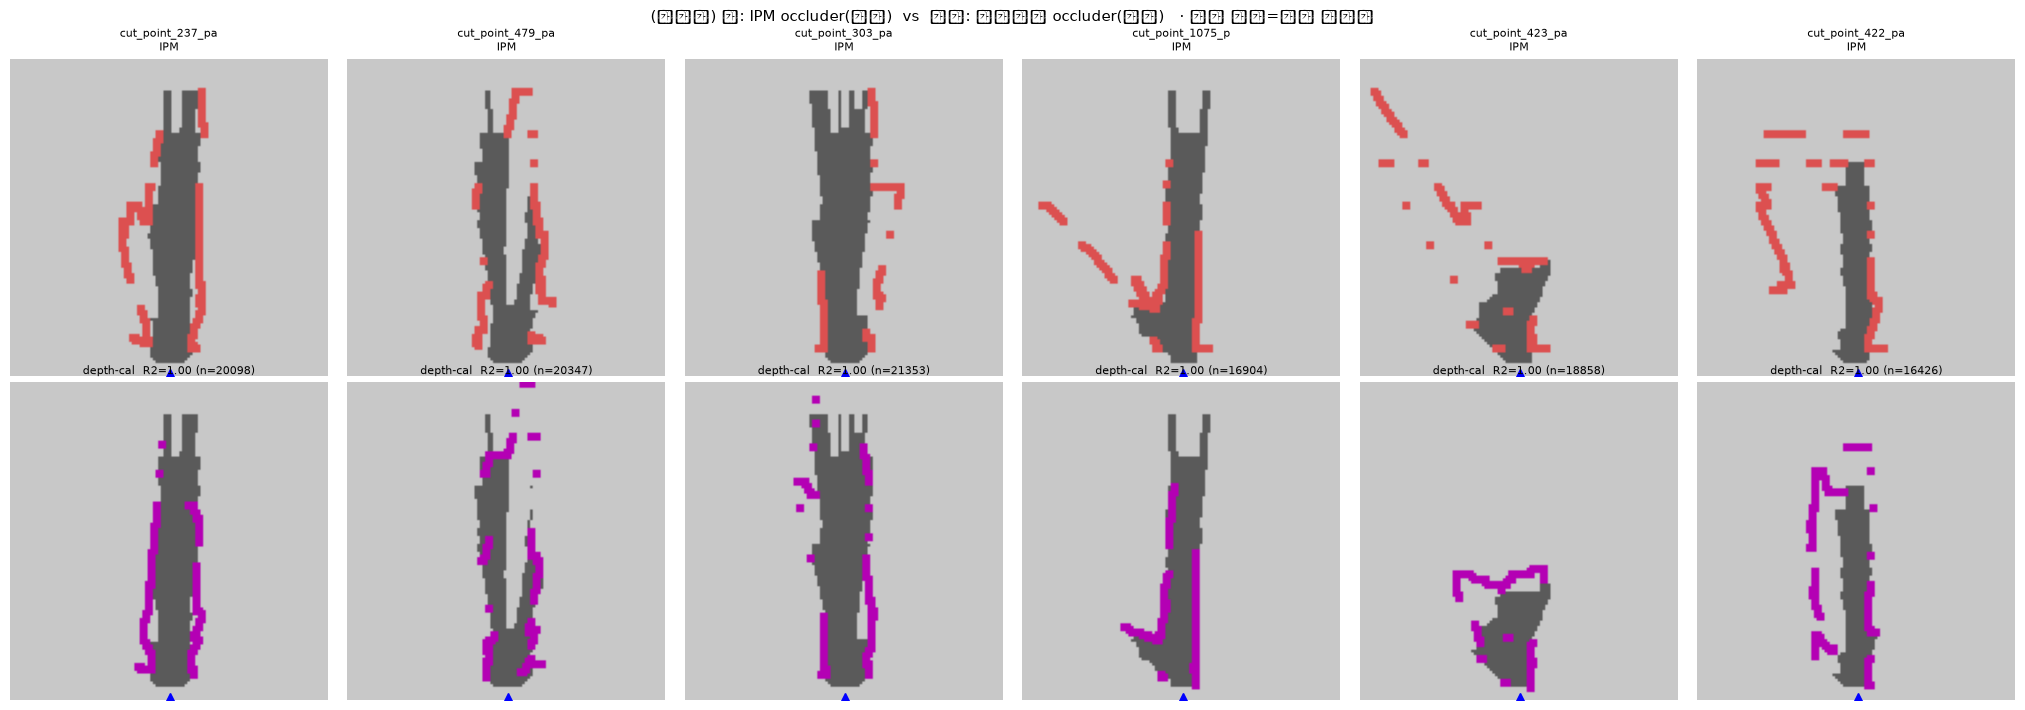

In [9]:
# (단일뷰 검증용 — 4방향 360 병합과 무관) 깊이 보정 occluder(자홍) vs IPM occluder(빨강) 비교.
# 정면 크롭 N장에 대해 단일뷰 좌표(전방=up)로 형상만 비교한다. 배경 회색 = 차도 코리도.
N_CMP = 6
_front_paths = sorted(FRONT_DIR.glob("*_front.jpg"))
_samples = random.Random().sample(_front_paths, min(N_CMP, len(_front_paths)))
fig, axes = plt.subplots(2, len(_samples), figsize=(3.4 * len(_samples), 7.2))

for j, img_path in enumerate(_samples):
    stem = img_path.stem   # 예: cut_point_1000_pano_xxx_front
    cam = json.load(open(FRONT_DIR / (stem + "_cam.json"), encoding="utf-8"))
    K = np.array(cam["K"])
    img_bgr = cv2.imread(str(img_path)); h, w = img_bgr.shape[:2]
    with np.load(DEPTH_DIR / (stem + "_depth.npz")) as dz:
        depth_norm = dz["depth_norm"].copy()
    with np.load(SEG_DIR / (stem + "_masks.npz")) as seg:
        sm = seg["masks"]
        obstacle_mask = sm.any(axis=0) if len(sm) else np.zeros((h, w), bool)
        ground_mask = seg["ground_mask"].copy() if "ground_mask" in seg.files else np.zeros((h, w), bool)
        road_mask   = seg["road_mask"].copy()   if "road_mask"   in seg.files else np.zeros((h, w), bool)
    if HOOD_MASK_FRAC > 0:
        ground_mask[int(h * (1 - HOOD_MASK_FRAC)):, :] = True
    valid = ~ground_mask

    bg = np.ones((GRID_H, GRID_W, 3), np.uint8) * 200
    bg[project_ground_surface(road_mask, K, CAM_HEIGHT)] = [90, 90, 90]   # 차도 코리도

    # 위: IPM occluder
    top = bg.copy(); top[mask_to_footprint(obstacle_mask & valid, K, CAM_HEIGHT, subsample=2)] = [220, 80, 80]
    axes[0, j].imshow(top, origin="upper"); axes[0, j].plot(ORIGIN[0], ORIGIN[1], "b^", ms=8)
    axes[0, j].set_title(f"{stem[:16]}\nIPM", fontsize=8); axes[0, j].axis("off")

    # 아래: 깊이보정 occluder
    cal = calibrate_depth_to_metric(depth_norm, road_mask, K, CAM_HEIGHT)
    bot = bg.copy()
    if cal is not None:
        z_map, npts, r2 = cal
        bot[footprint_from_zmap(obstacle_mask & valid, K, z_map)] = [180, 0, 180]
        ttl = f"depth-cal  R2={r2:.2f} (n={npts})"
    else:
        ttl = "depth-cal: 정합 실패(도로 부족)"
    axes[1, j].imshow(bot, origin="upper"); axes[1, j].plot(ORIGIN[0], ORIGIN[1], "b^", ms=8)
    axes[1, j].set_title(ttl, fontsize=8); axes[1, j].axis("off")

plt.suptitle("(단일뷰) 위: IPM occluder(빨강)  vs  아래: 깊이보정 occluder(자홍)   · 배경 회색=차도 코리도", fontsize=11)
plt.tight_layout()
plt.show()